<a href="https://colab.research.google.com/github/hwollwage/PCVK_2026/blob/main/week_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

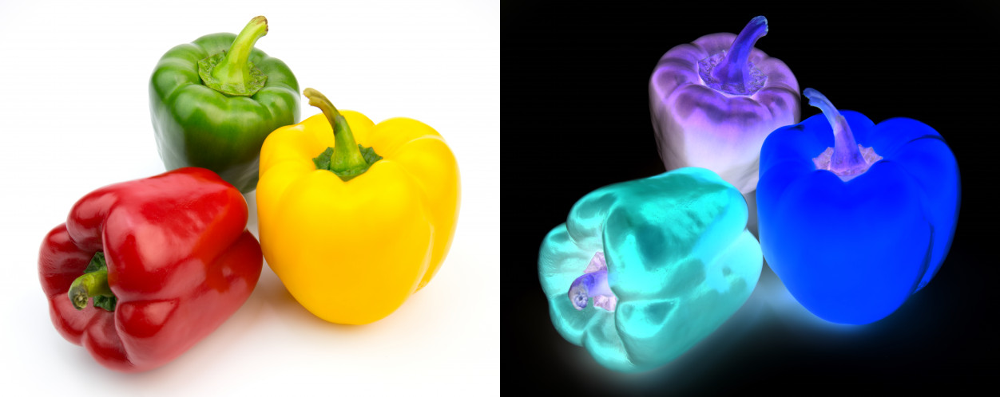

In [9]:
# 1 inverse
original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/peppers.jpg')

inverse_img = 255 - original
final_frame = cv2.hconcat((original, inverse_img))
cv2_imshow(final_frame)


enter brightness level: 20
enter contrast level: 1.5


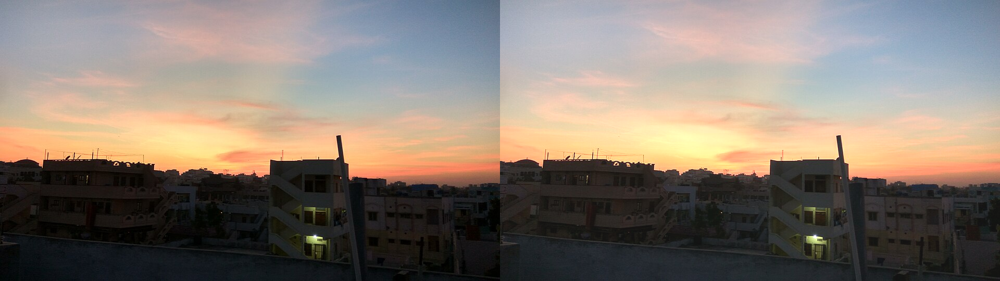

In [49]:
# 2 contrast
original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/sunset.jpg')

try:
  brightness = int(input("enter brightness level: "))
  contrast = float(input("enter contrast level: "))

except ValueError:
  print("error, not a num")

contrast_img = np.zeros(original.shape, original.dtype)
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      pixel = factor * (int(original[y,x,c]) - 128) + 128 + brightness
      contrast_img[y,x,c] = np.clip(pixel,0,255)

final_frame = cv2.hconcat((original, contrast_img))
cv2_imshow(final_frame)

enter brightness val: 50


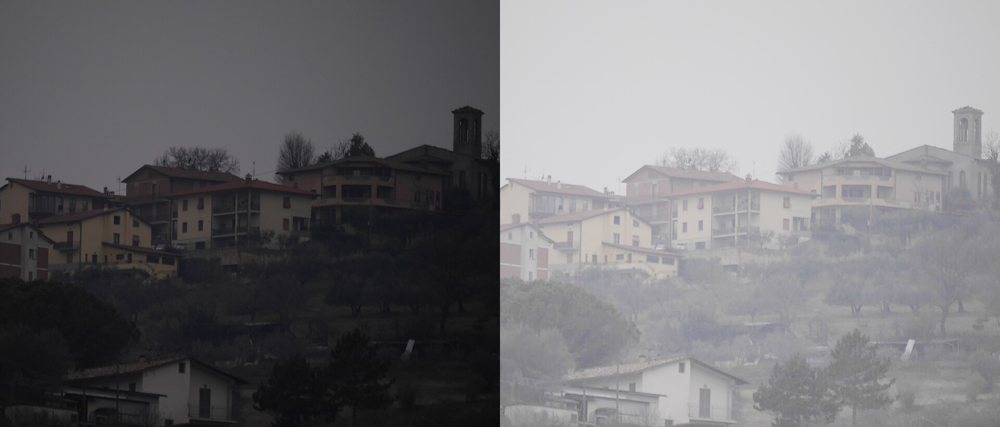

In [13]:
# 3 logarithmic brightness
original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/Underexposed_photo.JPG')

try:
  r_input = int(input('enter brightness val: '))
except ValueError:
  print('error, not a num')

img_float = original.astype(np.float64)

c = 255 / np.log(1+255)
log_img = c * np.log(1 + img_float)
log_img = np.clip(log_img,0,255).astype(np.uint8)

final_frame = cv2.hconcat((original, log_img))
cv2_imshow(final_frame)

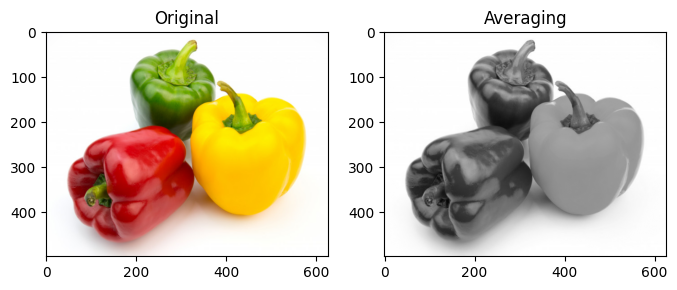

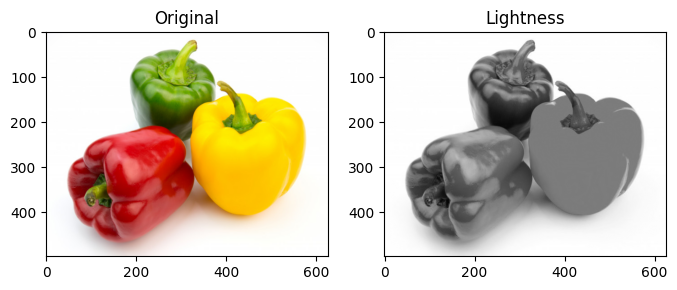

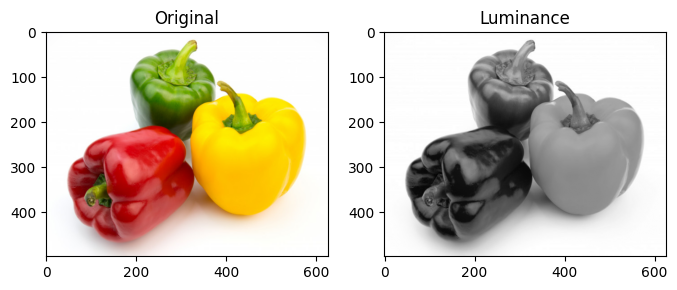

In [16]:
# 4 grayscaling (avg, lightness, luminance)
original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/peppers.jpg')

R = original[:,:,0].astype(np.float64)
G = original[:,:,1].astype(np.float64)
B = original[:,:,2].astype(np.float64)

gray_avg = ((R + G + B) / 3).astype(np.uint8)
gray_lightness = (((np.maximum(np.maximum(R, G), B)) + (np.minimum(np.minimum(R, G), B))) / 2).astype(np.uint8)
gray_luminance = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

# a. avg
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')
axs[1].imshow(gray_avg, cmap='gray'); axs[1].set_title('Averaging')
plt.show()

# b. lightness
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')
axs[1].imshow(gray_lightness, cmap='gray'); axs[1].set_title('Lightness')
plt.show()

# c. luminance
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')
axs[1].imshow(gray_luminance, cmap='gray'); axs[1].set_title('Luminance')
plt.show()


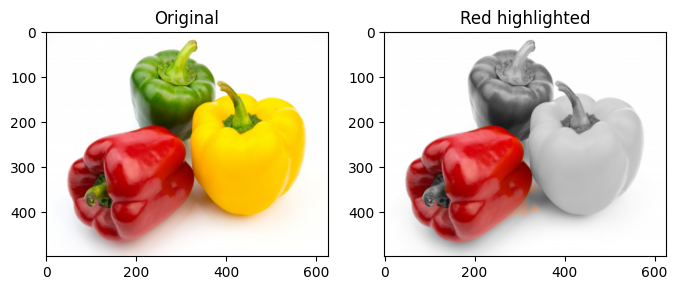

In [21]:
# 5 show 1 color and the rest is gray

original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/peppers.jpg')
hsv = cv2.cvtColor(original, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0, 70, 50]);   upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50]); upper_red2 = np.array([180, 255, 255])
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(mask1, mask2)

gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

result = np.where(red_mask[:, :, None] == 255, original, gray_3ch)

fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')
axs[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axs[1].set_title('Red highlighted')
plt.show()

Masukkan nilai Gamma: 2


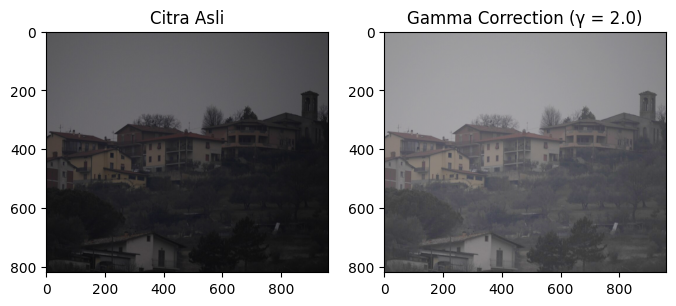

In [24]:
# 6 gamma

original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/Underexposed_photo.JPG')

try:
  gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')

img_float = original.astype(np.float64) / 255.0

gamma_image = 255 * (img_float ** (1/gamma))
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axs[0].set_title('Citra Asli')
axs[1].imshow(cv2.cvtColor(gamma_image, cv2.COLOR_BGR2RGB)); axs[1].set_title(f'Gamma Correction (γ = {gamma})')
plt.show()

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


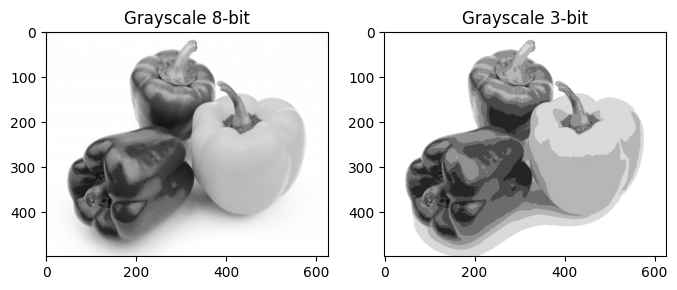

In [27]:
# 7 bit-depth

original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/peppers.jpg', cv2.IMREAD_GRAYSCALE)

bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
level = 255 / (pow(2, bit_depth) - 1)

depth_image = np.round((original / level)) * level
depth_image = depth_image.astype(np.uint8)

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {pow(2, bit_depth)}')

fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(original, cmap='gray'); axs[0].set_title('Grayscale 8-bit')
axs[1].imshow(depth_image, cmap='gray'); axs[1].set_title(f'Grayscale {bit_depth}-bit')
plt.show()

Jumlah citra: 10 -> PSNR = 19.74 dB


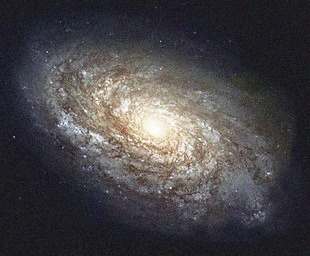

Jumlah citra: 20 -> PSNR = 19.84 dB


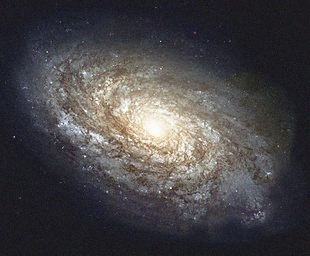

Jumlah citra: 40 -> PSNR = 19.89 dB


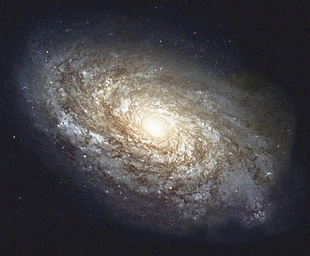

Jumlah citra: 80 -> PSNR = 19.92 dB


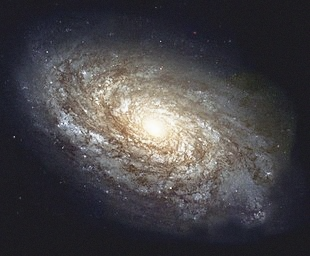

Jumlah citra: 100 -> PSNR = 19.92 dB


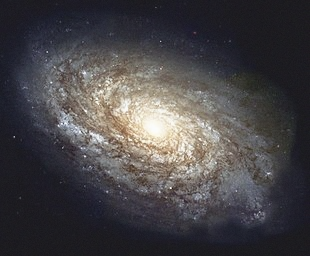

In [28]:
# 8 avg denoising + psnr
import glob

def PSNR(img1, img2):
  mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
  if mse == 0:
      return 100
  max_pixel = 255.0
  return 20 * np.log10(max_pixel / np.sqrt(mse))

original_clean = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/galaxy.jpg')

cv_img = []
for img_path in sorted(glob.glob('/content/drive/MyDrive/Colab Notebooks/gambar/noises/*.jpg')):
  n = cv2.imread(img_path)
  cv_img.append(n)

jumlah_list = [10, 20, 40, 80, 100]
hasil_psnr = {}

for jumlah in jumlah_list:
  subset = cv_img[:jumlah]
  avg_image = np.mean(subset, axis=0).astype(np.uint8)
  psnr_value = PSNR(original_clean, avg_image)
  hasil_psnr[jumlah] = psnr_value

  print(f'Jumlah citra: {jumlah} -> PSNR = {psnr_value:.2f} dB')
  cv2_imshow(avg_image)

dimensi: 256x256

ORIGINAL


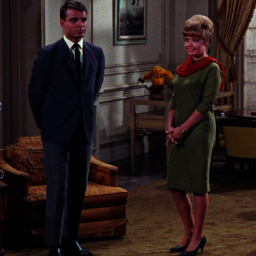

NOT


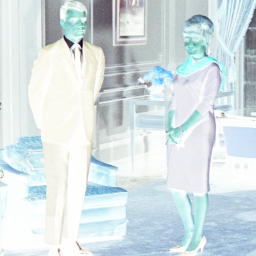

AND


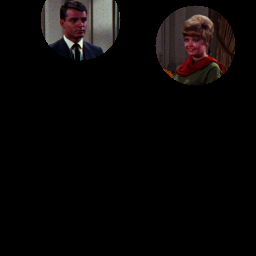

OR


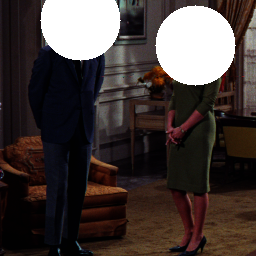

NAND


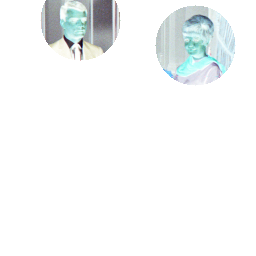

XOR


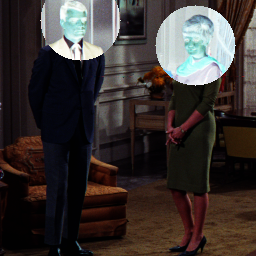

In [39]:
# 9 img masking

original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/couple.tiff')
h, w = original.shape[:2]
print(f"dimensi: {w}x{h}\n")

mask = np.zeros((h, w), dtype=np.uint8)
cv2.circle(mask, (80,20), 40, 255, -1)
cv2.circle(mask, (195,45), 40, 255, -1)
mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

not_result  = cv2.bitwise_not(original)
and_result  = cv2.bitwise_and(original, mask_3ch)
or_result   = cv2.bitwise_or(original, mask_3ch)
nand_result = cv2.bitwise_not(and_result)
xor_result  = cv2.bitwise_xor(original, mask_3ch)

for name, img in [('ORIGINAL', original), ('NOT', not_result), ('AND', and_result), ('OR', or_result),('NAND', nand_result), ('XOR', xor_result)]:
  print(name)
  cv2_imshow(img)

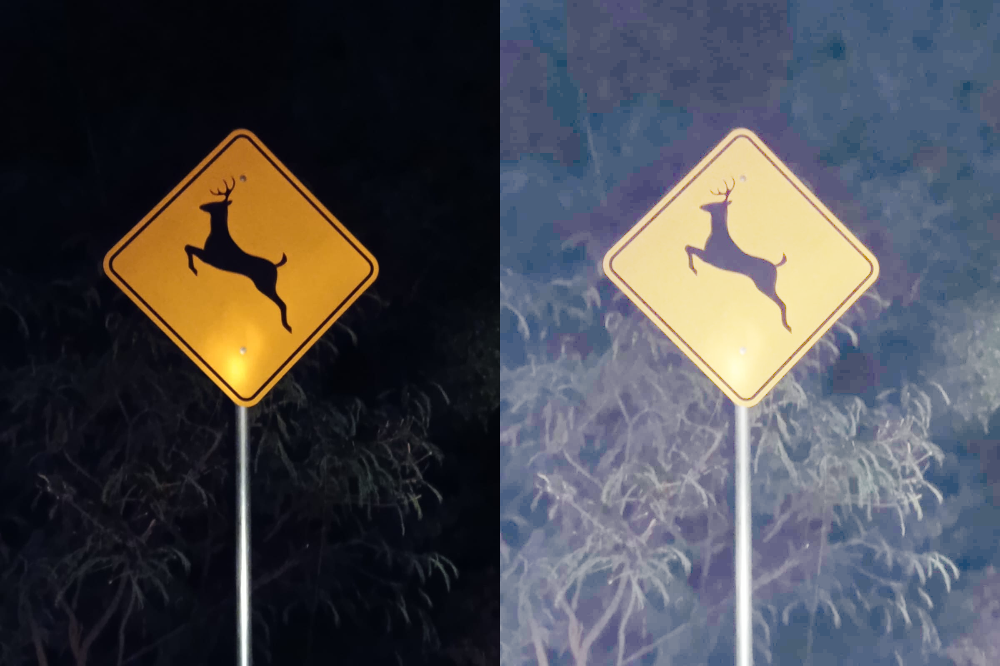

In [40]:
# 10 night photo
# i choose logarithmic brightness, because its the most suitable for dark image that isnt balanced
original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/malam.jpg')

img_float = original.astype(np.float64)
c = 255 / np.log(1 + 255)
log_image = np.clip(c * np.log(1 + img_float), 0, 255).astype(np.uint8)

final_frame = cv2.hconcat((original, log_image))
cv2_imshow(final_frame)

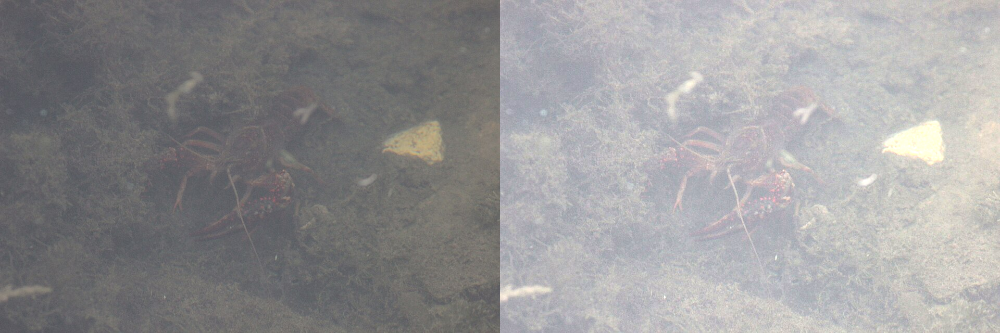

In [52]:
# 11 crayfish
# i use contrast & brightness to get the clear underwater that is in low contrast
original = cv2.imread('/content/drive/MyDrive/Colab Notebooks/gambar/crayfish.jpg')

# a (contrast) b (brightness)
a, b = 1.6, 20
enhanced = np.clip(a * original.astype(np.float64) + b, 0, 255).astype(np.uint8)

final_frame = cv2.hconcat((original, enhanced))
cv2_imshow(final_frame)